# Shape analysis

In [2]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("poster")

### Combination DAMIT & SSOFT

In [22]:
# You need SSOFT version 2024.09
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [23]:
ssoft

,ssnamenr,HG_chi2red,HG_status,HG_fit,HG_rms,HG_rms_g,HG_rms_r,HG_median_error_phot,HG_median_error_phot_1,HG_median_error_phot_2,...,n_days_g,n_days_r,last_jd,name,number,SSHG1G2_obliquity,SSHG1G2_alpha0_alt,SSHG1G2_delta0_alt,version,SSHG1G2_flag
0,101701,0.719543,1.0,0.0,0.093366,0.089528,0.094580,0.132646,0.155745,0.120481,...,539.029053,1460.968628,2460416.75,1999 CU149,101701,170.757358,284.300591,71.334122,2024.10,0
1,5905,3.219591,2.0,0.0,0.091977,0.095511,0.088604,0.056260,0.062858,0.050953,...,1716.129517,1693.042480,2460580.75,Johnson,5905,78.788507,355.578842,-28.077848,2024.10,0
2,17198,0.893037,2.0,0.0,0.074188,0.063565,0.081301,0.098897,0.113590,0.090610,...,1550.881226,1643.912964,2460433.75,Gorjup,17198,127.151531,119.133759,62.109669,2024.10,0
3,39393,1.275180,2.0,0.0,0.118609,0.093745,0.131462,0.124569,0.148834,0.108740,...,1043.688599,1597.776001,2460403.75,5564 P-L,39393,172.923357,291.874146,62.721329,2024.10,0
4,97374,0.410299,1.0,0.0,0.065731,0.068644,0.063882,0.111845,0.135781,0.101153,...,1402.045410,1451.910156,2460285.75,2000 AS65,97374,79.653140,44.025681,12.576742,2024.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140554,118736,1.772564,4.0,0.0,0.142969,0.140039,0.145454,0.129314,0.161984,0.104680,...,1512.839600,1518.712036,2460380.75,2000 QF132,118736,55.885930,354.124985,-41.008564,2024.10,0
140555,21431,8.882621,2.0,0.0,0.224519,0.225774,0.223517,0.091577,0.102337,0.075457,...,1579.914551,1581.846313,2460578.75,Amberhess,21431,53.686025,60.784882,-15.165733,2024.10,0
140556,102483,1.606714,2.0,0.0,0.080141,0.073762,0.086049,0.106194,0.108889,0.095425,...,1575.798706,1537.901123,2460431.75,1999 TA253,102483,175.678621,292.364746,65.674484,2024.10,0
140557,14412,1.542104,2.0,0.0,0.089844,0.095504,0.085587,0.080404,0.081900,0.076313,...,1667.036011,1665.934692,2460464.75,Wolflojewski,14412,8.304986,60.443558,-63.813835,2024.10,0


In [9]:
flavor = "SSHG1G2"

In [10]:
# put the period in hours
ssoft[f"{flavor}_period"] = 24 * ssoft[f"{flavor}_period"]

In [29]:
abc = pd.read_csv("../../data/damit_abc.csv")

# Revert b and c if needed 
cond_bc = abc['b'] < abc['c']
print('revert bc', len(abc[cond_bc]))

b = abc.loc[cond_bc,'b']
abc.loc[cond_bc,'b'] = abc.loc[cond_bc,'c']
abc.loc[cond_bc,'c'] = b

# Revert a and b if needed 
cond_ab = abc['a'] < abc['b']
print('revert ab', len(abc[cond_ab]))

a = abc.loc[cond_ab,'a']
abc.loc[cond_ab,'a'] = abc.loc[cond_ab,'b']
abc.loc[cond_ab,'b'] = a


# Revert b and c again if needed 
cond_bc = abc['b'] < abc['c']
print('revert bc', len(abc[cond_bc]))

b = abc.loc[cond_bc,'b']
abc.loc[cond_bc,'b'] = abc.loc[cond_bc,'c']
abc.loc[cond_bc,'c'] = b

# Check
cond_bc = abc['b'] < abc['c']
cond_ab = abc['a'] < abc['b']
print('miss ab, bc', len(abc[cond_ab]), len(abc[cond_bc]))

# abc[cond_bc]
abc

revert bc 0
revert ab 0
revert bc 0
miss ab, bc 0 0


,model_id,asteroid_id,lambda,beta,period,number,name,designation,reference_id,bibcode,a,b,c,R,R2
0,101,101,35.0,-12.0,7.813230,2.0,Pallas,NaN,106,2003icar..164..346t,0.050144,0.047520,0.044016,0.902027,0.902027
1,101,101,35.0,-12.0,7.813230,2.0,Pallas,NaN,139,2011icar..214..652d,0.050144,0.047520,0.044016,0.902027,0.902027
2,106,104,340.0,42.0,7.274471,6.0,Hebe,NaN,106,2003icar..164..346t,0.087539,0.084628,0.074940,0.870793,0.870799
3,106,104,340.0,42.0,7.274471,6.0,Hebe,NaN,139,2011icar..214..652d,0.087539,0.084628,0.074940,0.870793,0.870799
4,110,106,335.0,-5.0,12.866670,8.0,Flora,NaN,106,2003icar..164..346t,0.098508,0.093500,0.086202,0.898516,0.898511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16312,16275,10853,326.0,-83.0,8.016800,99949.0,Miepgies,NaN,665,2023arxiv230510798d,1.359332,0.883253,0.851780,0.795492,0.795492
16313,16276,10854,34.0,-42.0,143.500000,99973.0,NaN,NaN,665,2023arxiv230510798d,1.510920,0.870606,0.766555,0.693913,0.693914
16314,16277,10854,194.0,-64.0,143.490000,99973.0,NaN,NaN,665,2023arxiv230510798d,1.586496,0.873017,0.728478,0.646806,0.646806
16315,16278,10855,192.0,-52.0,7.071400,99990.0,NaN,NaN,665,2023arxiv230510798d,1.724247,0.872519,0.661044,0.570504,0.570504


## Comparison to literature

In [31]:
data = abc.merge(ssoft, left_on="name", right_on="name", how="left")

# sort by number of observations
data = data.sort_values("n_obs", ascending=False)
# data = data.sort_values(f'{flavor}_rms', ascending=False)

data["DAMIT_a_b"] = data["a"] / data["b"]
data["DAMIT_a_c"] = data["a"] / data["c"]

col_display = ["name", "DAMIT_a_b", "DAMIT_a_c", "SSHG1G2_a_b", "SSHG1G2_a_c"]

# DAMIT HAS DUPLICATES?
data = data.drop_duplicates("name")

data[col_display].head(50)

,name,DAMIT_a_b,DAMIT_a_c,SSHG1G2_a_b,SSHG1G2_a_c
13419,Briggs,1.625192,1.646537,1.805289,1.973068
399,Hektor,2.177053,2.407573,1.326712,1.847313
9934,Agamemnon,1.287346,1.568217,1.276487,1.747617
10909,Diomedes,1.559108,1.746083,1.660507,2.033727
5599,Brendelia,1.327214,1.345692,1.300437,1.880357
13790,Mariobotta,1.458461,1.550638,1.466553,1.462142
8469,Ajax,1.196356,1.411893,1.084837,1.132318
11240,Ennomos,1.239060,1.829367,1.022461,1.223338
1017,Anna,1.628478,2.187422,1.100484,1.256421
29951,Palamedes,1.269198,1.868966,1.243322,1.810182


### Distributions

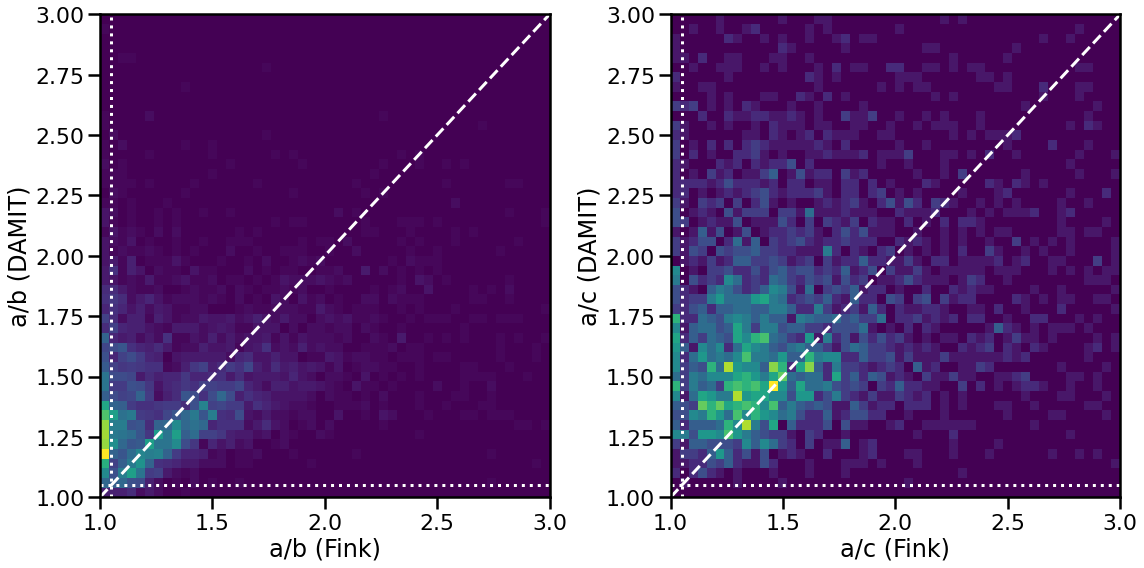

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

r_ab = [1, 3]
r_bc = [1, 3]
r_ac = [1, 3]
b_ab = 50
b_bc = 50
b_ac = 50

fields = ["a_b", "a_c"]
for index in range(2):
    axes[index].hist2d(
        data["SSHG1G2_{}".format(fields[index])], 
        data["DAMIT_{}".format(fields[index])], 
        range=[r_ab, r_bc], 
        bins=[b_ab, b_bc]
    )

    axes[index].axhline(1.05, color='white', ls=":")
    axes[index].axvline(1.05, color='white', ls=":")
    

    axes[index].plot(r_ab, r_bc, color="white", ls='--')
    axes[index].set_xlabel("{} (Fink)".format(fields[index]).replace("_", "/"))
    axes[index].set_ylabel("{} (DAMIT)".format(fields[index]).replace("_", "/"))

# axes[1].legend(prop={'size': 15})
plt.tight_layout()

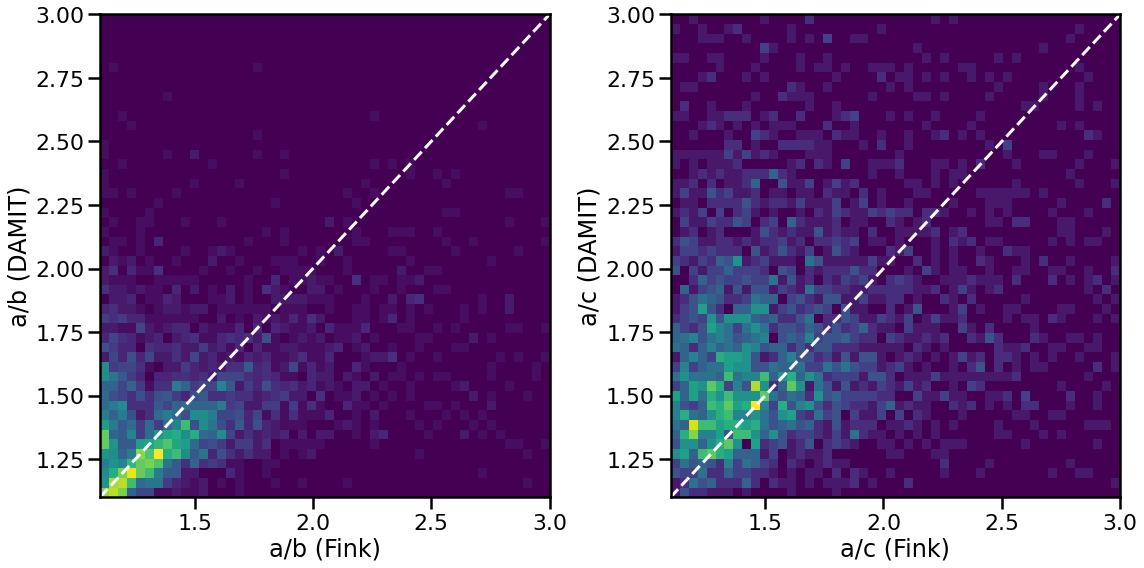

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

r_ab = [1.1, 3]
r_bc = [1.1, 3]
r_ac = [1.1, 3]
b_ab = 50
b_bc = 50
b_ac = 50

fields = ["a_b", "a_c"]
for index in range(2):
    axes[index].hist2d(
        data["SSHG1G2_{}".format(fields[index])], 
        data["DAMIT_{}".format(fields[index])], 
        range=[r_ab, r_bc], 
        bins=[b_ab, b_bc]
    )

    axes[index].axhline(1.05, color='white', ls=":")
    axes[index].axvline(1.05, color='white', ls=":")
    

    axes[index].plot(r_ab, r_bc, color="white", ls='--')
    axes[index].set_xlabel("{} (Fink)".format(fields[index]).replace("_", "/"))
    axes[index].set_ylabel("{} (DAMIT)".format(fields[index]).replace("_", "/"))

# axes[1].legend(prop={'size': 15})
plt.tight_layout()